# Analisis Sentimen Ulasan DANA Google Play

Notebook ini menggunakan dataset hasil scraping mandiri dari Google Play untuk aplikasi **DANA Dompet Digital Indonesia** (`id.dana`). Label sentimen utama dibuat dengan supervisi lemah berbasis kata sentimen pada teks ulasan. Label berbasis rating tetap disimpan sebagai `rating_sentiment` untuk audit: 1-2 negatif, 3 netral, 4-5 positif.

In [1]:
from pathlib import Path
import os
import sys
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'sentiment_pipeline.py').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay

from sentiment_pipeline import (
    LABEL_ORDER,
    balanced_training_frame,
    classical_experiments,
    load_dataset,
    predict_examples,
    save_best_classical,
    split_data,
    train_deep_learning_experiment,
)

pd.set_option('display.max_colwidth', 140)
sns.set_theme(style='whitegrid')

## 1. Memuat Dataset Hasil Scraping

In [2]:
df = load_dataset()
print('Jumlah data berlabel:', len(df))
display(df.head())
display(df[['score', 'rating_sentiment', 'sentiment']].value_counts().reset_index(name='jumlah').sort_values(['sentiment', 'score']))

Jumlah data berlabel: 11851


,reviewId,userName,content,clean_text,score,rating_sentiment,sentiment,at,appVersion,source_app_id,source_app_name
0,6c7567b0-a2b7-4524-82d3-66a7f714c74e,PRAY Priatna,"ini kenapa sihh,,masa mau top up pulsa semuanya stok habisss,,,ko dana bisa gitu ya...jelekkk",ini kenapa sihh masa mau top up pulsa semuanya stok habisss ko dana bisa gitu ya jelekkk,3,netral,positif,2026-05-29 21:01:13,2.127.0,id.dana,DANA Dompet Digital Indonesia
1,d0f90bc3-b26c-4742-8458-ec8d9f35817a,APNER “ALPNER” 06,bagus,bagus,5,positif,positif,2026-05-29 21:01:11,2.127.0,id.dana,DANA Dompet Digital Indonesia
2,ccef7915-daf7-440f-a6ca-8733f128e574,Safinatun Najat,"luar biasa, semoga dana tetap aman yaaa🫶",luar biasa semoga dana tetap aman yaaa,5,positif,positif,2026-05-29 21:00:18,2.125.3,id.dana,DANA Dompet Digital Indonesia
3,6aa1c700-e56a-41d5-a8ba-4e6000a28a48,Andri Junaedi,mntappp,mntappp,5,positif,netral,2026-05-29 21:00:06,2.126.0,id.dana,DANA Dompet Digital Indonesia
4,c80b190b-f42b-4c7c-b2c2-dfe1e1fedb7f,Wawanlabangka,sangat mambantu dalam sehari sehari untuk belanja,sangat mambantu dalam sehari sehari untuk belanja,5,positif,netral,2026-05-29 21:00:03,2.127.0,id.dana,DANA Dompet Digital Indonesia


,score,rating_sentiment,sentiment,jumlah
3,1,negatif,negatif,1368
10,2,negatif,negatif,199
11,3,netral,negatif,152
13,4,positif,negatif,88
7,5,positif,negatif,286
2,1,negatif,netral,1637
6,2,negatif,netral,364
4,3,netral,netral,418
5,4,positif,netral,397
1,5,positif,netral,2967


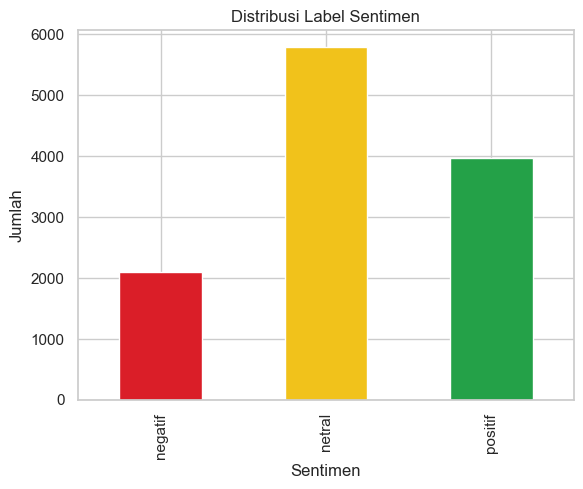

In [3]:
ax = df['sentiment'].value_counts().reindex(LABEL_ORDER).plot(kind='bar', color=['#da1e28', '#f1c21b', '#24a148'])
ax.set_title('Distribusi Label Sentimen')
ax.set_xlabel('Sentimen')
ax.set_ylabel('Jumlah')
plt.show()

## 2. Menyiapkan Data Training yang Seimbang

In [4]:
train_df = balanced_training_frame(df)
print('Jumlah data training seimbang:', len(train_df))
display(train_df['sentiment'].value_counts().reindex(LABEL_ORDER))
x_train, x_test, y_train, y_test = split_data(train_df)
print('Train:', len(x_train), 'Test:', len(x_test))

Jumlah data training seimbang: 6279


sentiment
negatif    2093
netral     2093
positif    2093
Name: count, dtype: int64

Train: 5023 Test: 1256


## 3. Skema 1 dan 2: Machine Learning Klasik + TF-IDF

In [5]:
classical_results = classical_experiments(x_train, x_test, y_train, y_test)
for result in classical_results:
    print('\n===', result.name, '===')
    print('Akurasi training:', round(result.train_accuracy, 4))
    print('Akurasi testing :', round(result.test_accuracy, 4))
    print(result.report)


=== Logistic Regression + TF-IDF ===
Akurasi training: 0.997
Akurasi testing : 0.9283
              precision    recall  f1-score   support

     negatif       0.89      0.97      0.93       418
      netral       0.94      0.87      0.90       419
     positif       0.97      0.95      0.96       419

    accuracy                           0.93      1256
   macro avg       0.93      0.93      0.93      1256
weighted avg       0.93      0.93      0.93      1256


=== Linear SVM + TF-IDF ===
Akurasi training: 0.9982
Akurasi testing : 0.9427
              precision    recall  f1-score   support

     negatif       0.92      0.97      0.94       418
      netral       0.94      0.89      0.92       419
     positif       0.97      0.97      0.97       419

    accuracy                           0.94      1256
   macro avg       0.94      0.94      0.94      1256
weighted avg       0.94      0.94      0.94      1256



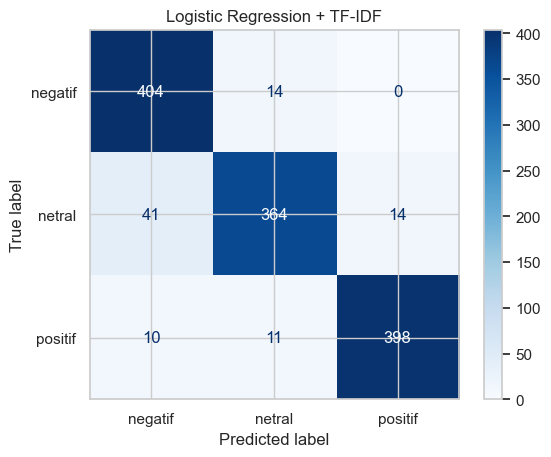

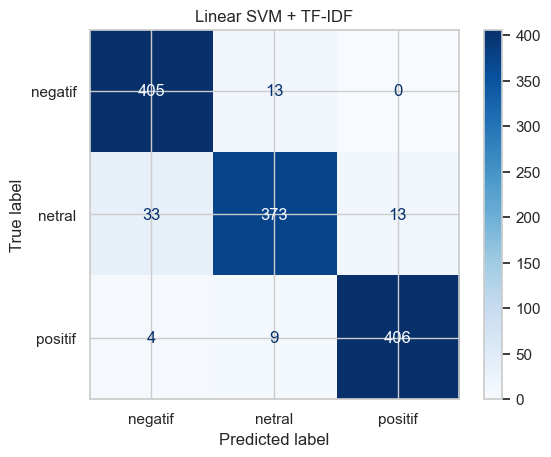

In [6]:
for result in classical_results:
    disp = ConfusionMatrixDisplay(result.confusion, display_labels=LABEL_ORDER)
    disp.plot(cmap='Blues', values_format='d')
    plt.title(result.name)
    plt.show()

## 4. Skema 3: Deep Learning Ringan

In [7]:
try:
    dl_result = train_deep_learning_experiment(x_train, x_test, y_train, y_test)
    print('\n===', dl_result['name'], '===')
    print('Akurasi training:', round(dl_result['train_accuracy'], 4))
    print('Akurasi testing :', round(dl_result['test_accuracy'], 4))
    print(dl_result['report'])
except Exception as exc:
    dl_result = None
    print('Percobaan deep learning tidak dapat dijalankan di lingkungan ini:', repr(exc))

Epoch 1/8


 1/63 ━━━━━━━━━━━━━━━━━━━━ 3:30 3s/step - accuracy: 0.2812 - loss: 1.0983

 3/63 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.3203 - loss: 1.0975

 5/63 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.3502 - loss: 1.0967

 7/63 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.3740 - loss: 1.0959

...

61/63 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.9977 - loss: 0.0086

62/63 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.9977 - loss: 0.0086

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.9977 - loss: 0.0087

63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 77ms/step - accuracy: 0.9978 - loss: 0.0097 - val_accuracy: 0.9572 - val_loss: 0.1835



=== BiLSTM + Keras TextVectorization ===
Akurasi training: 0.9918
Akurasi testing : 0.953
              precision    recall  f1-score   support

     negatif       0.94      0.96      0.95       418
      netral       0.92      0.94      0.93       419
     positif       0.99      0.96      0.98       419

    accuracy                           0.95      1256
   macro avg       0.95      0.95      0.95      1256
weighted avg       0.95      0.95      0.95      1256



## 5. Perbandingan Hasil dan Penyimpanan Model

In [8]:
rows = [
    {'scheme': result.name, 'train_accuracy': result.train_accuracy, 'test_accuracy': result.test_accuracy}
    for result in classical_results
]
if dl_result is not None:
    rows.append({
        'scheme': dl_result['name'],
        'train_accuracy': dl_result['train_accuracy'],
        'test_accuracy': dl_result['test_accuracy'],
    })
comparison = pd.DataFrame(rows).sort_values('test_accuracy', ascending=False)
display(comparison)
best = save_best_classical(classical_results)
print('Model klasik terbaik disimpan ke models/best_tfidf_svm.joblib:', best.name)

,scheme,train_accuracy,test_accuracy
2,BiLSTM + Keras TextVectorization,0.991838,0.953025
1,Linear SVM + TF-IDF,0.998208,0.942675
0,Logistic Regression + TF-IDF,0.997014,0.928344


Model klasik terbaik disimpan ke models/best_tfidf_svm.joblib: Linear SVM + TF-IDF


## 6. Inference / Testing Manual

In [9]:
examples = [
    'aplikasi dana sangat membantu transaksi cepat dan mudah digunakan',
    'saldo saya hilang dan customer service lambat sekali',
    'fiturnya biasa saja kadang lancar kadang error',
]
display(predict_examples(best.model, examples))

,teks,prediksi_sentimen
0,aplikasi dana sangat membantu transaksi cepat dan mudah digunakan,positif
1,saldo saya hilang dan customer service lambat sekali,negatif
2,fiturnya biasa saja kadang lancar kadang error,netral
